# DistilBERT W4 architecture-stratified sensitivity and W4/W8 transfer study

This shortened experiment preserves the complete **872-example labelled SST-2 development split** while reducing compute through a predefined 15-tensor architecture-stratified sample. The sample spans embeddings, early/middle/late attention, feed-forward transformations, pooler and classifier.

The notebook compares custom per-channel 4-bit PTQ and scalar codebook W4 ($K=16$) against Notebook 18's saved W8 results. It also asks a report-worthy question: **does an 8-bit sensitivity ranking identify tensors that should remain FP32 in a 4-bit model?**

All activations and Keras arithmetic remain FP32. No retraining or fake-quantization operators are used. Sub-byte memory values are theoretical packed-storage estimates including scale or codebook overhead.

In [1]:
from pathlib import Path
import gc, json, platform, sys, time

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import binomtest, pearsonr, spearmanr
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists(): raise RuntimeError("Run from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from src.models import DISTILBERT_BASE_EN_UNCASED_PRESET, SST2_CLASS_NAMES, build_distilbert_text_preprocessor
from src.quantization.custom_quantization import (
    codebook_vectorize_model_n_bits, custom_ptq_n_bits, dequantize_tensor, reconstruct_codebook_tensor,
)
print(f"Python: {sys.version.split()[0]}; TensorFlow: {tf.__version__}; Keras: {keras.__version__}; SciPy: {scipy.__version__}")
print(f"Hardware: {platform.platform()}")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7; TensorFlow: 2.20.0; Keras: 3.14.1; SciPy: 1.18.0
Hardware: macOS-26.5.2-arm64-arm-64bit-Mach-O


## 1. Fixed, compute-bounded protocol

The subset is fixed before observing W4 results, preventing W4-driven cherry-picking. Notebook 18 remains the complete 40-tensor W8 analysis; this notebook is a matched cross-bit study rather than a complete W4 census.

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "sst2" / "SST-2"
DEV_PATH = DATA_DIR / "dev.tsv"
MODEL_PATH = PROJECT_ROOT / "artifacts" / "distilbert_sst2_ptq" / "distilbert_sst2_fp32.keras"
W8_OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "distilbert_full_layer_sensitivity"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "distilbert_4bit_stratified_sensitivity"
LOCAL_VOCAB_PATH = Path.home() / ".cache" / "kagglehub" / "models" / "keras" / "distil_bert" / "keras" / "distil_bert_base_en_uncased" / "3" / "assets" / "tokenizer" / "vocabulary.txt"
CACHE_VERSION = "v1_w4_stratified15_k16_full_sst2_dev"
CACHE_DIR = OUTPUT_DIR / "cache" / CACHE_VERSION
PREDICTION_CACHE_DIR = CACHE_DIR / "predictions"
RECONSTRUCTION_CACHE_DIR = CACHE_DIR / "reconstructed_weights"

PRESET = DISTILBERT_BASE_EN_UNCASED_PRESET
NUM_BITS, CODEBOOK_SIZE, CODEBOOK_VECTOR_DIM = 4, 16, 1
SEQUENCE_LENGTH, NUM_EVALUATION_EXAMPLES, BATCH_SIZE = 128, 872, 32
PTQ_PER_CHANNEL = True
CODEBOOK_DTYPE, CODEBOOK_ITERATIONS, CODEBOOK_MAX_SAMPLES = np.float32, 30, 100_000
BOOTSTRAP_REPETITIONS, RANDOM_SEED = 2_000, 42
PROTECTION_COUNT = 3
FORCE_RECOMPUTE = False
METHODS = {
    "ptq_w4": "Custom per-channel 4-bit PTQ",
    "codebook_w4": "Custom scalar codebook W4 (K=16)",
}
METHOD_FAMILY = {"ptq_w4": "ptq", "codebook_w4": "codebook"}

# Architecture-stratified sample: embeddings; early/middle/late attention and FFN; output head.
STRATIFIED_TENSORS = [
    "token_and_position_embedding/token_embedding/embeddings",
    "token_and_position_embedding/position_embedding/embeddings",
    "transformer_layer_0/self_attention_layer/query/kernel",
    "transformer_layer_0/self_attention_layer/attention_output/kernel",
    "transformer_layer_0/feedforward_output_dense/kernel",
    "transformer_layer_2/self_attention_layer/query/kernel",
    "transformer_layer_2/self_attention_layer/value/kernel",
    "transformer_layer_2/self_attention_layer/attention_output/kernel",
    "transformer_layer_2/feedforward_intermediate_dense/kernel",
    "transformer_layer_2/feedforward_output_dense/kernel",
    "transformer_layer_5/self_attention_layer/query/kernel",
    "transformer_layer_5/self_attention_layer/attention_output/kernel",
    "transformer_layer_5/feedforward_output_dense/kernel",
    "pooled_dense/kernel",
    "logits/kernel",
]
for path in (MODEL_PATH, DEV_PATH, W8_OUTPUT_DIR / "layerwise_sensitivity_all_methods.csv", W8_OUTPUT_DIR / "selective_quantization_all_configurations.csv"):
    if not path.exists(): raise FileNotFoundError(path)
for directory in (OUTPUT_DIR, PREDICTION_CACHE_DIR, RECONSTRUCTION_CACHE_DIR): directory.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)
print(f"W4 subset: {len(STRATIFIED_TENSORS)} tensors; evaluation examples: {NUM_EVALUATION_EXAMPLES}")
print(f"Output: {OUTPUT_DIR}")

W4 subset: 15 tensors; evaluation examples: 872
Output: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/distilbert_4bit_stratified_sensitivity


## 2. Load and tokenize the complete labelled SST-2 development set

In [3]:
dev_frame = pd.read_csv(DEV_PATH, sep="\t")
test_texts = dev_frame.sentence.astype(str).to_numpy()
test_labels = dev_frame.label.astype(np.int32).to_numpy()
assert len(test_texts) == len(test_labels) == NUM_EVALUATION_EXAMPLES
if LOCAL_VOCAB_PATH.exists():
    tokenizer = keras_hub.models.DistilBertTokenizer(str(LOCAL_VOCAB_PATH), lowercase=True)
    preprocessor = keras_hub.models.DistilBertTextClassifierPreprocessor(tokenizer, sequence_length=SEQUENCE_LENGTH)
    print(f"Using cached vocabulary: {LOCAL_VOCAB_PATH}")
else:
    preprocessor = build_distilbert_text_preprocessor(sequence_length=SEQUENCE_LENGTH)

def tokenize_texts(texts, batch_size=256):
    chunks = {"token_ids": [], "padding_mask": []}
    for start in range(0, len(texts), batch_size):
        encoded = preprocessor(tf.constant(texts[start:start + batch_size]))
        for name in chunks: chunks[name].append(encoded[name].numpy().astype(np.int32))
    return {name: np.concatenate(values) for name, values in chunks.items()}

test_inputs = tokenize_texts(test_texts)
print({name: values.shape for name, values in test_inputs.items()})
display(dev_frame.head())

Using cached vocabulary: /Users/sahil/.cache/kagglehub/models/keras/distil_bert/keras/distil_bert_base_en_uncased/3/assets/tokenizer/vocabulary.txt
{'token_ids': (872, 128), 'padding_mask': (872, 128)}


,sentence,label
0,it 's a charming and often affecting journey .,1
1,unflinchingly bleak and desperate,0
2,allows us to hope that nolan is poised to emba...,1
3,"the acting , costumes , music , cinematography...",1
4,"it 's slow -- very , very slow .",0


## 3. Load the checkpoint and verify complete and stratified coverage

In [4]:
model = keras.models.load_model(MODEL_PATH, compile=False)
baseline_weights = [weight.numpy() for weight in model.weights]
fp32_parameter_bytes = int(sum(values.nbytes for values in baseline_weights))

def tensor_role(name):
    if name.endswith("/embeddings"): return "embedding"
    if "self_attention_layer" in name: return "attention_projection"
    if "feedforward" in name: return "feedforward"
    if name.startswith("pooled_dense"): return "pooled_projection"
    if name.startswith("logits"): return "classifier"
    return "other_kernel"

def depth_group(name):
    if name.startswith("token_and_position"): return "input"
    if name.startswith("transformer_layer_0"): return "early"
    if name.startswith("transformer_layer_2"): return "middle"
    if name.startswith("transformer_layer_5"): return "late"
    return "output"

candidate_rows = []
for weight_index, (weight, values) in enumerate(zip(model.weights, baseline_weights)):
    name = getattr(weight, "path", weight.name)
    if np.issubdtype(values.dtype, np.floating) and values.ndim >= 2 and (name.endswith("/kernel") or name.endswith("/embeddings")):
        candidate_rows.append({
            "tensor_index": len(candidate_rows), "weight_index": weight_index, "tensor": name,
            "module": name.rsplit("/", 1)[0], "role": tensor_role(name), "depth_group": depth_group(name),
            "rank": values.ndim, "shape": tuple(values.shape), "parameter_count": int(values.size), "fp32_bytes": int(values.nbytes),
        })
candidate_table = pd.DataFrame(candidate_rows)
assert len(candidate_table) == 40
candidate_names = candidate_table.tensor.tolist()
candidate_by_name = candidate_table.set_index("tensor").to_dict(orient="index")
missing = set(STRATIFIED_TENSORS) - set(candidate_names)
if missing: raise ValueError(f"Missing stratified tensors: {sorted(missing)}")
stratified_table = candidate_table[candidate_table.tensor.isin(STRATIFIED_TENSORS)].copy()
stratified_table["sample_order"] = stratified_table.tensor.map({name: i for i, name in enumerate(STRATIFIED_TENSORS)})
stratified_table = stratified_table.sort_values("sample_order")
print(f"Complete eligible coverage: {len(candidate_table)} tensors; stratified sensitivity subset: {len(stratified_table)}")
print(f"FP32 parameter storage: {fp32_parameter_bytes / 1024**2:.2f} MiB")
display(stratified_table[["sample_order", "tensor", "depth_group", "role", "parameter_count"]])

Complete eligible coverage: 40 tensors; stratified sensitivity subset: 15
FP32 parameter storage: 255.41 MiB


/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 210 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,sample_order,tensor,depth_group,role,parameter_count
0,0,token_and_position_embedding/token_embedding/e...,input,embedding,23440896
1,1,token_and_position_embedding/position_embeddin...,input,embedding,393216
2,2,transformer_layer_0/self_attention_layer/query...,early,attention_projection,589824
5,3,transformer_layer_0/self_attention_layer/atten...,early,attention_projection,589824
7,4,transformer_layer_0/feedforward_output_dense/k...,early,feedforward,2359296
14,5,transformer_layer_2/self_attention_layer/query...,middle,attention_projection,589824
16,6,transformer_layer_2/self_attention_layer/value...,middle,attention_projection,589824
17,7,transformer_layer_2/self_attention_layer/atten...,middle,attention_projection,589824
18,8,transformer_layer_2/feedforward_intermediate_d...,middle,feedforward,2359296
19,9,transformer_layer_2/feedforward_output_dense/k...,middle,feedforward,2359296


## 4. Resumable inference, reconstruction and paired-statistics helpers

In [5]:
evaluation_model = keras.models.load_model(MODEL_PATH, compile=False)

def slice_inputs(inputs, start, stop): return {name: values[start:stop] for name, values in inputs.items()}
def predict_logits(keras_model, inputs, batch_size=BATCH_SIZE):
    count = len(next(iter(inputs.values()))); batches = []
    for start in range(0, count, batch_size):
        batches.append(keras_model(slice_inputs(inputs, start, start + batch_size), training=False).numpy())
    return np.concatenate(batches).astype(np.float32)
def prediction_cache_path(tag): return PREDICTION_CACHE_DIR / f"{tag}.npz"
def evaluate_weights(tag, weights):
    path = prediction_cache_path(tag)
    if path.exists() and not FORCE_RECOMPUTE:
        with np.load(path) as cached: logits, predictions = cached["logits"], cached["predictions"]
        if len(predictions) != NUM_EVALUATION_EXAMPLES: raise ValueError(f"Stale cache: {path}")
        return logits, predictions, True
    evaluation_model.set_weights(weights); logits = predict_logits(evaluation_model, test_inputs)
    predictions = np.argmax(logits, axis=1).astype(np.int16); np.savez_compressed(path, logits=logits, predictions=predictions)
    return logits, predictions, False
def weights_with_replacements(replacements, selected_names):
    weights = baseline_weights.copy()
    for name in selected_names: weights[candidate_by_name[name]["weight_index"]] = replacements[name]
    return weights

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 210 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [6]:
def reconstruction_cache_path(method, tensor_index): return RECONSTRUCTION_CACHE_DIR / f"{method}_tensor_{tensor_index:02d}.npz"

def prepare_reconstructions(method):
    cached_reconstructed, cached_storage, complete = {}, {}, True
    for row in candidate_table.itertuples(index=False):
        path = reconstruction_cache_path(method, row.tensor_index)
        if not path.exists() or FORCE_RECOMPUTE: complete = False; break
        with np.load(path) as cached:
            cached_reconstructed[row.tensor] = cached["reconstructed"]
            cached_storage[row.tensor] = int(cached["storage_bytes"])
    if complete:
        print(f"Loaded all {len(candidate_table)} {method} reconstructions from cache.")
        return cached_reconstructed, cached_storage

    names = set(candidate_names)
    if method == "ptq_w4":
        result = custom_ptq_n_bits(model, num_bits=NUM_BITS, per_channel=PTQ_PER_CHANNEL, included_tensor_names=names)["weights"]
        tensors = result.tensors
        reconstruct = dequantize_tensor
        storage = lambda t: int((t.values.size * NUM_BITS + 7) // 8 + np.asarray(t.scale).nbytes)
    elif method == "codebook_w4":
        result = codebook_vectorize_model_n_bits(
            model, num_bits=NUM_BITS, vector_dim=CODEBOOK_VECTOR_DIM, mode="vector", included_tensor_names=names,
            codebook_dtype=CODEBOOK_DTYPE, max_kmeans_samples=CODEBOOK_MAX_SAMPLES, kmeans_iterations=CODEBOOK_ITERATIONS, seed=RANDOM_SEED,
        )
        tensors = result.tensors; reconstruct = reconstruct_codebook_tensor
        storage = lambda t: int(t.estimated_compressed_size_bytes)
    else: raise ValueError(method)
    reconstructed_by_name, storage_by_name = {}, {}
    for tensor in tensors:
        dtype = baseline_weights[candidate_by_name[tensor.name]["weight_index"]].dtype
        reconstructed = reconstruct(tensor).astype(dtype); storage_bytes = storage(tensor)
        row = candidate_by_name[tensor.name]; path = reconstruction_cache_path(method, row["tensor_index"])
        np.savez_compressed(path, reconstructed=reconstructed, storage_bytes=storage_bytes)
        reconstructed_by_name[tensor.name], storage_by_name[tensor.name] = reconstructed, storage_bytes
    if set(reconstructed_by_name) != names: raise RuntimeError(f"Incomplete {method} reconstruction coverage.")
    return reconstructed_by_name, storage_by_name

def weight_error_metrics(original, reconstructed):
    original64, reconstructed64 = np.asarray(original, np.float64), np.asarray(reconstructed, np.float64)
    error = original64 - reconstructed64; squared_error, signal = float(np.sum(error ** 2)), float(np.sum(original64 ** 2))
    denominator = np.linalg.norm(original64.ravel()) * np.linalg.norm(reconstructed64.ravel())
    return {
        "weight_mse": squared_error / original64.size, "weight_nmse": squared_error / signal if signal else 0.0,
        "weight_mae": float(np.mean(np.abs(error))), "max_absolute_weight_error": float(np.max(np.abs(error))),
        "weight_cosine_similarity": float(np.dot(original64.ravel(), reconstructed64.ravel()) / denominator) if denominator else 1.0,
        "weight_sqnr_db": float("inf") if squared_error == 0 else float(10 * np.log10(signal / squared_error)),
    }

In [7]:
def paired_outcome_metrics(reference_predictions, candidate_predictions, labels, seed):
    reference_correct, candidate_correct = reference_predictions == labels, candidate_predictions == labels
    cc = int(np.sum(reference_correct & candidate_correct)); cw = int(np.sum(reference_correct & ~candidate_correct))
    wc = int(np.sum(~reference_correct & candidate_correct)); ww = int(np.sum(~reference_correct & ~candidate_correct))
    differences = reference_correct.astype(np.int8) - candidate_correct.astype(np.int8)
    counts = np.array([np.sum(differences == -1), np.sum(differences == 0), np.sum(differences == 1)])
    draws = np.random.default_rng(seed).multinomial(len(labels), counts / len(labels), size=BOOTSTRAP_REPETITIONS)
    delta = (draws[:, 2] - draws[:, 0]) / len(labels) * 100; discordant = cw + wc
    return {
        "correct_to_correct": cc, "correct_to_wrong": cw, "wrong_to_correct": wc, "wrong_to_wrong": ww,
        "prediction_disagreement_percent": float(np.mean(reference_predictions != candidate_predictions) * 100),
        "bootstrap_ci_low_pp": float(np.percentile(delta, 2.5)), "bootstrap_ci_high_pp": float(np.percentile(delta, 97.5)),
        "mcnemar_p_value": float(binomtest(cw, discordant, 0.5).pvalue) if discordant else 1.0,
    }
def benjamini_hochberg(p_values):
    values = np.asarray(p_values, np.float64); order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1); ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked); adjusted[order] = np.clip(ranked, 0, 1); return adjusted
def representation_size_bytes(method, quantized_names):
    size = fp32_parameter_bytes
    for name in set(quantized_names):
        size -= candidate_by_name[name]["fp32_bytes"]; size += storage_by_method[method][name]
    return int(size)

## 5. Prepare all W4 weights once and evaluate the FP32 baseline

All 40 eligible tensors are reconstructed once so full-W4 and selective configurations remain available. Only the predefined 15 tensors receive isolated sensitivity evaluations.

In [8]:
reconstructed_by_method, storage_by_method = {}, {}
for method, label in METHODS.items():
    print(f"Preparing {label}")
    reconstructed_by_method[method], storage_by_method[method] = prepare_reconstructions(method)

fp32_logits, fp32_predictions, cache_hit = evaluate_weights("fp32_full_sst2_dev", baseline_weights)
fp32_accuracy = float(np.mean(fp32_predictions == test_labels))
print(f"FP32 accuracy: {fp32_accuracy * 100:.2f}% ({np.sum(fp32_predictions == test_labels)}/{NUM_EVALUATION_EXAMPLES}); cache={cache_hit}")

Preparing Custom per-channel 4-bit PTQ
Preparing Custom scalar codebook W4 (K=16)
FP32 accuracy: 88.42% (771/872); cache=False


## 6. Isolated W4 sensitivity on the 15-tensor stratified sample

In [9]:
rows = []; sensitivity_path = OUTPUT_DIR / "w4_stratified_tensor_sensitivity.csv"
total = len(METHODS) * len(stratified_table); run = 0
for method_index, (method, label) in enumerate(METHODS.items()):
    for candidate in stratified_table.itertuples(index=False):
        run += 1; start = time.perf_counter(); print(f"[{run:02d}/{total:02d}] {label}: {candidate.tensor}")
        weights = baseline_weights.copy(); weights[candidate.weight_index] = reconstructed_by_method[method][candidate.tensor]
        tag = f"stratified_{method}_{candidate.tensor_index:02d}_full_sst2_dev"
        _, predictions, cache_hit = evaluate_weights(tag, weights); accuracy = float(np.mean(predictions == test_labels))
        row = {
            "method": method, "method_family": METHOD_FAMILY[method], "method_label": label, "bit_width": NUM_BITS,
            "tensor_index": candidate.tensor_index, "tensor": candidate.tensor, "module": candidate.module,
            "role": candidate.role, "depth_group": candidate.depth_group, "parameter_count": candidate.parameter_count,
            "fp32_accuracy_percent": fp32_accuracy * 100, "quantized_accuracy_percent": accuracy * 100,
            "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
            "prediction_cache_tag": tag, "evaluation_seconds": time.perf_counter() - start, "cache_hit": cache_hit,
        }
        row.update(weight_error_metrics(baseline_weights[candidate.weight_index], reconstructed_by_method[method][candidate.tensor]))
        row.update(paired_outcome_metrics(fp32_predictions, predictions, test_labels, RANDOM_SEED + method_index * 1000 + candidate.tensor_index))
        rows.append(row); pd.DataFrame(rows).to_csv(sensitivity_path, index=False)
        print(f"    accuracy={accuracy * 100:.2f}% | drop={row['accuracy_degradation_pp']:+.2f} pp | disagreement={row['prediction_disagreement_percent']:.2f}% | cache={cache_hit}")

w4_results = pd.DataFrame(rows); w4_results["mcnemar_fdr_p_value"] = np.nan
for method in METHODS:
    mask = w4_results.method == method; w4_results.loc[mask, "mcnemar_fdr_p_value"] = benjamini_hochberg(w4_results.loc[mask, "mcnemar_p_value"])
w4_results = w4_results.sort_values(["method", "accuracy_degradation_pp", "prediction_disagreement_percent"], ascending=[True, False, False])
w4_results["subset_sensitivity_rank"] = w4_results.groupby("method").cumcount() + 1
w4_results.to_csv(sensitivity_path, index=False); evaluation_model.set_weights(baseline_weights); gc.collect()
display(w4_results[["method_label", "subset_sensitivity_rank", "tensor", "depth_group", "role", "weight_nmse", "quantized_accuracy_percent", "accuracy_degradation_pp", "prediction_disagreement_percent", "bootstrap_ci_low_pp", "bootstrap_ci_high_pp", "mcnemar_fdr_p_value"]])

[01/30] Custom per-channel 4-bit PTQ: token_and_position_embedding/token_embedding/embeddings
    accuracy=88.76% | drop=-0.34 pp | disagreement=1.49% | cache=False
[02/30] Custom per-channel 4-bit PTQ: token_and_position_embedding/position_embedding/embeddings
    accuracy=88.30% | drop=+0.11 pp | disagreement=0.34% | cache=False
[03/30] Custom per-channel 4-bit PTQ: transformer_layer_0/self_attention_layer/query/kernel
    accuracy=88.53% | drop=-0.11 pp | disagreement=0.34% | cache=False
[04/30] Custom per-channel 4-bit PTQ: transformer_layer_0/self_attention_layer/attention_output/kernel
    accuracy=88.42% | drop=+0.00 pp | disagreement=0.23% | cache=False
[05/30] Custom per-channel 4-bit PTQ: transformer_layer_0/feedforward_output_dense/kernel
    accuracy=88.42% | drop=+0.00 pp | disagreement=0.46% | cache=False
[06/30] Custom per-channel 4-bit PTQ: transformer_layer_2/self_attention_layer/query/kernel
    accuracy=88.30% | drop=+0.11 pp | disagreement=0.34% | cache=False
[07/30

,method_label,subset_sensitivity_rank,tensor,depth_group,role,weight_nmse,quantized_accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,bootstrap_ci_low_pp,bootstrap_ci_high_pp,mcnemar_fdr_p_value
23,Custom scalar codebook W4 (K=16),1,transformer_layer_2/feedforward_intermediate_d...,middle,feedforward,0.015295,88.188073,0.229358,0.917431,-0.344037,0.802752,1.0
18,Custom scalar codebook W4 (K=16),2,transformer_layer_0/self_attention_layer/atten...,early,attention_projection,0.019527,88.188073,0.229358,0.458716,-0.229358,0.688073,1.0
24,Custom scalar codebook W4 (K=16),3,transformer_layer_2/feedforward_output_dense/k...,middle,feedforward,0.040177,88.188073,0.229358,0.458716,-0.229358,0.688073,1.0
25,Custom scalar codebook W4 (K=16),4,transformer_layer_5/self_attention_layer/query...,late,attention_projection,0.014647,88.188073,0.229358,0.229358,0.000000,0.573394,1.0
21,Custom scalar codebook W4 (K=16),5,transformer_layer_2/self_attention_layer/value...,middle,attention_projection,0.012979,88.302752,0.114679,0.344037,-0.229358,0.573394,1.0
20,Custom scalar codebook W4 (K=16),6,transformer_layer_2/self_attention_layer/query...,middle,attention_projection,0.011719,88.417431,0.000000,0.458716,-0.458716,0.458716,1.0
29,Custom scalar codebook W4 (K=16),7,logits/kernel,output,classifier,0.005800,88.417431,0.000000,0.000000,0.000000,0.000000,1.0
15,Custom scalar codebook W4 (K=16),8,token_and_position_embedding/token_embedding/e...,input,embedding,0.009707,88.532110,-0.114679,1.032110,-0.802752,0.573394,1.0
17,Custom scalar codebook W4 (K=16),9,transformer_layer_0/self_attention_layer/query...,early,attention_projection,0.015059,88.532110,-0.114679,0.114679,-0.344037,0.000000,1.0
19,Custom scalar codebook W4 (K=16),10,transformer_layer_0/feedforward_output_dense/k...,early,feedforward,0.022114,88.532110,-0.114679,0.114679,-0.344037,0.000000,1.0


## 7. Join the matched Notebook 18 W8 results

Ranks are recomputed within the identical 15-tensor subset. This supports fair cross-bit rank stability, additional W4 degradation, and reconstruction-error amplification analysis.

In [10]:
w8_all = pd.read_csv(W8_OUTPUT_DIR / "layerwise_sensitivity_all_methods.csv")
w8_all["method_family"] = w8_all.method.map({"ptq_w8": "ptq", "codebook_w8": "codebook"})
w8_subset = w8_all[w8_all.tensor.isin(STRATIFIED_TENSORS)].copy()
assert len(w8_subset) == len(METHODS) * len(STRATIFIED_TENSORS)
w8_subset = w8_subset.sort_values(["method", "accuracy_degradation_pp", "prediction_disagreement_percent"], ascending=[True, False, False])
w8_subset["subset_sensitivity_rank"] = w8_subset.groupby("method").cumcount() + 1

metrics = ["quantized_accuracy_percent", "accuracy_degradation_pp", "prediction_disagreement_percent", "weight_mse", "weight_nmse", "weight_sqnr_db", "subset_sensitivity_rank"]
w4_join = w4_results[["method_family", "tensor", "depth_group", "role", "parameter_count"] + metrics].rename(columns={m: f"{m}_w4" for m in metrics})
w8_join = w8_subset[["method_family", "tensor"] + metrics].rename(columns={m: f"{m}_w8" for m in metrics})
comparison = w4_join.merge(w8_join, on=["method_family", "tensor"], validate="one_to_one")
comparison["additional_w4_degradation_pp"] = comparison.accuracy_degradation_pp_w4 - comparison.accuracy_degradation_pp_w8
comparison["additional_w4_disagreement_percent"] = comparison.prediction_disagreement_percent_w4 - comparison.prediction_disagreement_percent_w8
comparison["nmse_amplification_w4_over_w8"] = comparison.weight_nmse_w4 / comparison.weight_nmse_w8.replace(0, np.nan)
comparison["rank_change_w4_minus_w8"] = comparison.subset_sensitivity_rank_w4 - comparison.subset_sensitivity_rank_w8
comparison = comparison.sort_values(["method_family", "accuracy_degradation_pp_w4"], ascending=[True, False])
comparison.to_csv(OUTPUT_DIR / "matched_tensor_sensitivity_w4_vs_w8.csv", index=False)
display(comparison)

,method_family,tensor,depth_group,role,parameter_count,quantized_accuracy_percent_w4,accuracy_degradation_pp_w4,prediction_disagreement_percent_w4,weight_mse_w4,weight_nmse_w4,...,accuracy_degradation_pp_w8,prediction_disagreement_percent_w8,weight_mse_w8,weight_nmse_w8,weight_sqnr_db_w8,subset_sensitivity_rank_w8,additional_w4_degradation_pp,additional_w4_disagreement_percent,nmse_amplification_w4_over_w8,rank_change_w4_minus_w8
0,codebook,transformer_layer_2/feedforward_intermediate_d...,middle,feedforward,2359296,88.188073,0.229358,0.917431,0.000032,0.015295,...,0.229358,0.229358,1.775837e-06,0.000836,30.777885,1,0.000000e+00,6.880734e-01,18.295733,0
1,codebook,transformer_layer_0/self_attention_layer/atten...,early,attention_projection,589824,88.188073,0.229358,0.458716,0.000024,0.019527,...,0.000000,0.000000,8.074714e-07,0.000667,31.759603,4,2.293578e-01,4.587156e-01,29.281203,-2
2,codebook,transformer_layer_2/feedforward_output_dense/k...,middle,feedforward,2359296,88.188073,0.229358,0.458716,0.000081,0.040177,...,0.114679,0.344037,4.409504e-05,0.021957,16.584361,2,1.146789e-01,1.146789e-01,1.829829,1
3,codebook,transformer_layer_5/self_attention_layer/query...,late,attention_projection,589824,88.188073,0.229358,0.229358,0.000036,0.014647,...,0.000000,0.000000,4.678482e-07,0.000193,37.146899,6,2.293578e-01,2.293578e-01,75.933048,-2
4,codebook,transformer_layer_2/self_attention_layer/value...,middle,attention_projection,589824,88.302752,0.114679,0.344037,0.000023,0.012979,...,0.000000,0.000000,8.733238e-08,0.000049,43.107247,5,1.146789e-01,3.440367e-01,265.438324,0
5,codebook,transformer_layer_2/self_attention_layer/query...,middle,attention_projection,589824,88.417431,0.000000,0.458716,0.000026,0.011719,...,-0.114679,0.114679,1.372863e-07,0.000061,42.155755,11,1.146789e-01,3.440367e-01,192.518426,-5
6,codebook,logits/kernel,output,classifier,1536,88.417431,0.000000,0.000000,0.000002,0.005800,...,0.000000,0.000000,6.369700e-09,0.000019,47.200663,9,0.000000e+00,0.000000e+00,304.452378,-2
7,codebook,token_and_position_embedding/token_embedding/e...,input,embedding,23440896,88.532110,-0.114679,1.032110,0.000036,0.009707,...,-0.229358,0.229358,1.919199e-07,0.000052,42.820103,14,1.146789e-01,8.027523e-01,185.820790,-6
8,codebook,transformer_layer_0/self_attention_layer/query...,early,attention_projection,589824,88.532110,-0.114679,0.114679,0.000028,0.015059,...,0.000000,0.000000,1.866343e-07,0.000099,40.030988,3,-1.146789e-01,1.146789e-01,151.672630,6
9,codebook,transformer_layer_0/feedforward_output_dense/k...,early,feedforward,2359296,88.532110,-0.114679,0.114679,0.000040,0.022114,...,-0.114679,0.114679,4.151810e-06,0.002272,26.435256,10,-4.163336e-17,1.387779e-17,9.731575,0


In [11]:
summary_rows = []
for family, group in comparison.groupby("method_family"):
    rank_corr = spearmanr(group.subset_sensitivity_rank_w4, group.subset_sensitivity_rank_w8)
    degradation_corr = spearmanr(group.accuracy_degradation_pp_w4, group.accuracy_degradation_pp_w8)
    summary_rows.append({
        "method_family": family, "sampled_tensors": len(group),
        "mean_degradation_w4_pp": group.accuracy_degradation_pp_w4.mean(), "mean_degradation_w8_pp": group.accuracy_degradation_pp_w8.mean(),
        "maximum_degradation_w4_pp": group.accuracy_degradation_pp_w4.max(), "maximum_degradation_w8_pp": group.accuracy_degradation_pp_w8.max(),
        "mean_disagreement_w4_percent": group.prediction_disagreement_percent_w4.mean(), "mean_disagreement_w8_percent": group.prediction_disagreement_percent_w8.mean(),
        "median_nmse_amplification_w4_over_w8": group.nmse_amplification_w4_over_w8.median(),
        "rank_stability_spearman_rho": rank_corr.statistic, "rank_stability_p": rank_corr.pvalue,
        "degradation_spearman_rho": degradation_corr.statistic, "degradation_spearman_p": degradation_corr.pvalue,
    })
comparison_summary = pd.DataFrame(summary_rows)
comparison_summary.to_csv(OUTPUT_DIR / "w4_w8_cross_bit_summary.csv", index=False)
display(comparison_summary)

,method_family,sampled_tensors,mean_degradation_w4_pp,mean_degradation_w8_pp,maximum_degradation_w4_pp,maximum_degradation_w8_pp,mean_disagreement_w4_percent,mean_disagreement_w8_percent,median_nmse_amplification_w4_over_w8,rank_stability_spearman_rho,rank_stability_p,degradation_spearman_rho,degradation_spearman_p
0,codebook,15,-0.007645,-0.038226,0.229358,0.229358,0.374618,0.099388,75.933048,0.692857,0.004190,0.712982,0.002848
1,ptq,15,-0.038226,-0.022936,0.114679,0.000000,0.420489,0.053517,327.979512,0.142857,0.611522,0.105992,0.706952


## 8. Full-W4 and cross-bit sensitivity-transfer configurations

Each method evaluates only three W4 configurations: full W4, protection of the globally top-three W8-sensitive tensors from Notebook 18, and protection of the top-three W4-sensitive tensors within the predefined sample. This replaces the 60 random-control evaluations used in the complete notebook.

In [12]:
def evaluate_configuration(method, configuration, protected_names):
    protected_names = set(protected_names); quantized_names = [name for name in candidate_names if name not in protected_names]
    tag = f"config_{method}_{configuration}_full_sst2_dev"
    _, predictions, cache_hit = evaluate_weights(tag, weights_with_replacements(reconstructed_by_method[method], quantized_names))
    accuracy = float(np.mean(predictions == test_labels)); size = representation_size_bytes(method, quantized_names)
    row = {
        "method": method, "method_family": METHOD_FAMILY[method], "method_label": METHODS[method], "bit_width": NUM_BITS,
        "configuration": configuration, "protected_tensors": len(protected_names), "quantized_tensors": len(quantized_names),
        "protected_tensor_names": " | ".join(sorted(protected_names)), "correct_predictions": int(np.sum(predictions == test_labels)),
        "evaluation_examples": NUM_EVALUATION_EXAMPLES, "accuracy_percent": accuracy * 100,
        "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100, "parameter_mib": size / 1024**2,
        "compression_ratio_vs_fp32": fp32_parameter_bytes / size, "memory_reduction_percent": (1 - size / fp32_parameter_bytes) * 100, "cache_hit": cache_hit,
    }
    row.update({f"fp32_{key}": value for key, value in paired_outcome_metrics(fp32_predictions, predictions, test_labels, RANDOM_SEED).items() if key in {"prediction_disagreement_percent", "mcnemar_p_value"}})
    return row

configuration_rows = []
for method in METHODS:
    family = METHOD_FAMILY[method]
    w8_group = w8_all[w8_all.method_family == family].sort_values(["accuracy_degradation_pp", "prediction_disagreement_percent"], ascending=[False, False])
    w8_top = w8_group.head(PROTECTION_COUNT).tensor.tolist()
    w4_top = w4_results[w4_results.method == method].head(PROTECTION_COUNT).tensor.tolist()
    print(f"Evaluating shortened configurations for {METHODS[method]}")
    configuration_rows.append(evaluate_configuration(method, "full_w4", []))
    configuration_rows.append(evaluate_configuration(method, "protect_w8_global_top3", w8_top))
    configuration_rows.append(evaluate_configuration(method, "protect_w4_subset_top3", w4_top))
w4_configurations = pd.DataFrame(configuration_rows)
w4_configurations.to_csv(OUTPUT_DIR / "short_w4_selective_configurations.csv", index=False)
display(w4_configurations)

Evaluating shortened configurations for Custom per-channel 4-bit PTQ
Evaluating shortened configurations for Custom scalar codebook W4 (K=16)


,method,method_family,method_label,bit_width,configuration,protected_tensors,quantized_tensors,protected_tensor_names,correct_predictions,evaluation_examples,accuracy_percent,accuracy_degradation_pp,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,cache_hit,fp32_prediction_disagreement_percent,fp32_mcnemar_p_value
0,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,full_w4,0,40,,776,872,88.990826,-0.573394,32.252945,7.919063,87.372243,False,2.637615,0.404873
1,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,protect_w8_global_top3,3,37,transformer_layer_1/self_attention_layer/value...,771,872,88.417431,0.000000,49.956802,5.112679,80.440783,False,2.522936,1.000000
2,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,protect_w4_subset_top3,3,37,token_and_position_embedding/position_embeddin...,775,872,88.876147,-0.458716,43.394302,5.885867,83.010150,False,2.752294,0.541256
3,codebook_w4,codebook,Custom scalar codebook W4 (K=16),4,full_w4,0,40,,770,872,88.302752,0.114679,32.136726,7.947701,87.417745,False,3.325688,1.000000
4,codebook_w4,codebook,Custom scalar codebook W4 (K=16),4,protect_w8_global_top3,3,37,transformer_layer_1/feedforward_output_dense/k...,771,872,88.417431,0.000000,55.761543,4.580452,78.168095,False,3.211009,1.000000
5,codebook_w4,codebook,Custom scalar codebook W4 (K=16),4,protect_w4_subset_top3,3,37,transformer_layer_0/self_attention_layer/atten...,772,872,88.532110,-0.114679,49.855293,5.123089,80.480526,False,3.096330,1.000000


In [13]:
w8_configs = pd.read_csv(W8_OUTPUT_DIR / "selective_quantization_all_configurations.csv")
w8_configs["method_family"] = w8_configs.method.map({"ptq_w8": "ptq", "codebook_w8": "codebook"})
w8_full = w8_configs[w8_configs.configuration == "full_w8"][[
    "method_family", "correct_predictions", "evaluation_examples", "accuracy_percent", "accuracy_degradation_pp", "prediction_disagreement_percent", "parameter_mib", "compression_ratio_vs_fp32", "memory_reduction_percent"
]].copy()
w8_full["bit_width"], w8_full["configuration"] = 8, "full_w8"
w4_full = w4_configurations[w4_configurations.configuration == "full_w4"].copy()
w4_full["prediction_disagreement_percent"] = w4_full.fp32_prediction_disagreement_percent
full_model_comparison = pd.concat([w4_full, w8_full], ignore_index=True, sort=False)[[
    "method_family", "bit_width", "configuration", "correct_predictions", "evaluation_examples", "accuracy_percent", "accuracy_degradation_pp", "prediction_disagreement_percent", "parameter_mib", "compression_ratio_vs_fp32", "memory_reduction_percent"
]].sort_values(["method_family", "bit_width"])
full_model_comparison.to_csv(OUTPUT_DIR / "full_model_w4_vs_w8.csv", index=False)
display(full_model_comparison)

,method_family,bit_width,configuration,correct_predictions,evaluation_examples,accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent
1,codebook,4,full_w4,770,872,88.302752,0.114679,3.325688,32.136726,7.947701,87.417745
3,codebook,8,full_w8,768,872,88.073394,0.344037,1.490826,64.070320,3.986449,74.915021
0,ptq,4,full_w4,776,872,88.990826,-0.573394,2.637615,32.252945,7.919063,87.372243
2,ptq,8,full_w8,771,872,88.417431,0.000000,0.229358,64.149918,3.981503,74.883857


## 9. Class-specific effects for full W4

SST-2 has different FP32 performance on negative and positive examples. Reporting both classes prevents aggregate accuracy from hiding a redistribution of errors.

In [14]:
class_rows = []
for method in METHODS:
    tag = f"config_{method}_full_w4_full_sst2_dev"
    with np.load(prediction_cache_path(tag)) as cached: predictions = cached["predictions"]
    for class_index, class_name in enumerate(SST2_CLASS_NAMES):
        mask = test_labels == class_index
        fp_acc = float(np.mean(fp32_predictions[mask] == test_labels[mask])); q_acc = float(np.mean(predictions[mask] == test_labels[mask]))
        class_rows.append({
            "method": method, "class_name": class_name, "examples": int(mask.sum()),
            "fp32_accuracy_percent": fp_acc * 100, "w4_accuracy_percent": q_acc * 100, "accuracy_degradation_pp": (fp_acc - q_acc) * 100,
        })
class_table = pd.DataFrame(class_rows); class_table.to_csv(OUTPUT_DIR / "full_w4_per_class.csv", index=False)
display(class_table)

,method,class_name,examples,fp32_accuracy_percent,w4_accuracy_percent,accuracy_degradation_pp
0,ptq_w4,negative,428,82.009346,82.710280,-0.700935
1,ptq_w4,positive,444,94.594595,95.045045,-0.450450
2,codebook_w4,negative,428,82.009346,81.542056,0.467290
3,codebook_w4,positive,444,94.594595,94.819820,-0.225225


## 10. Report figures

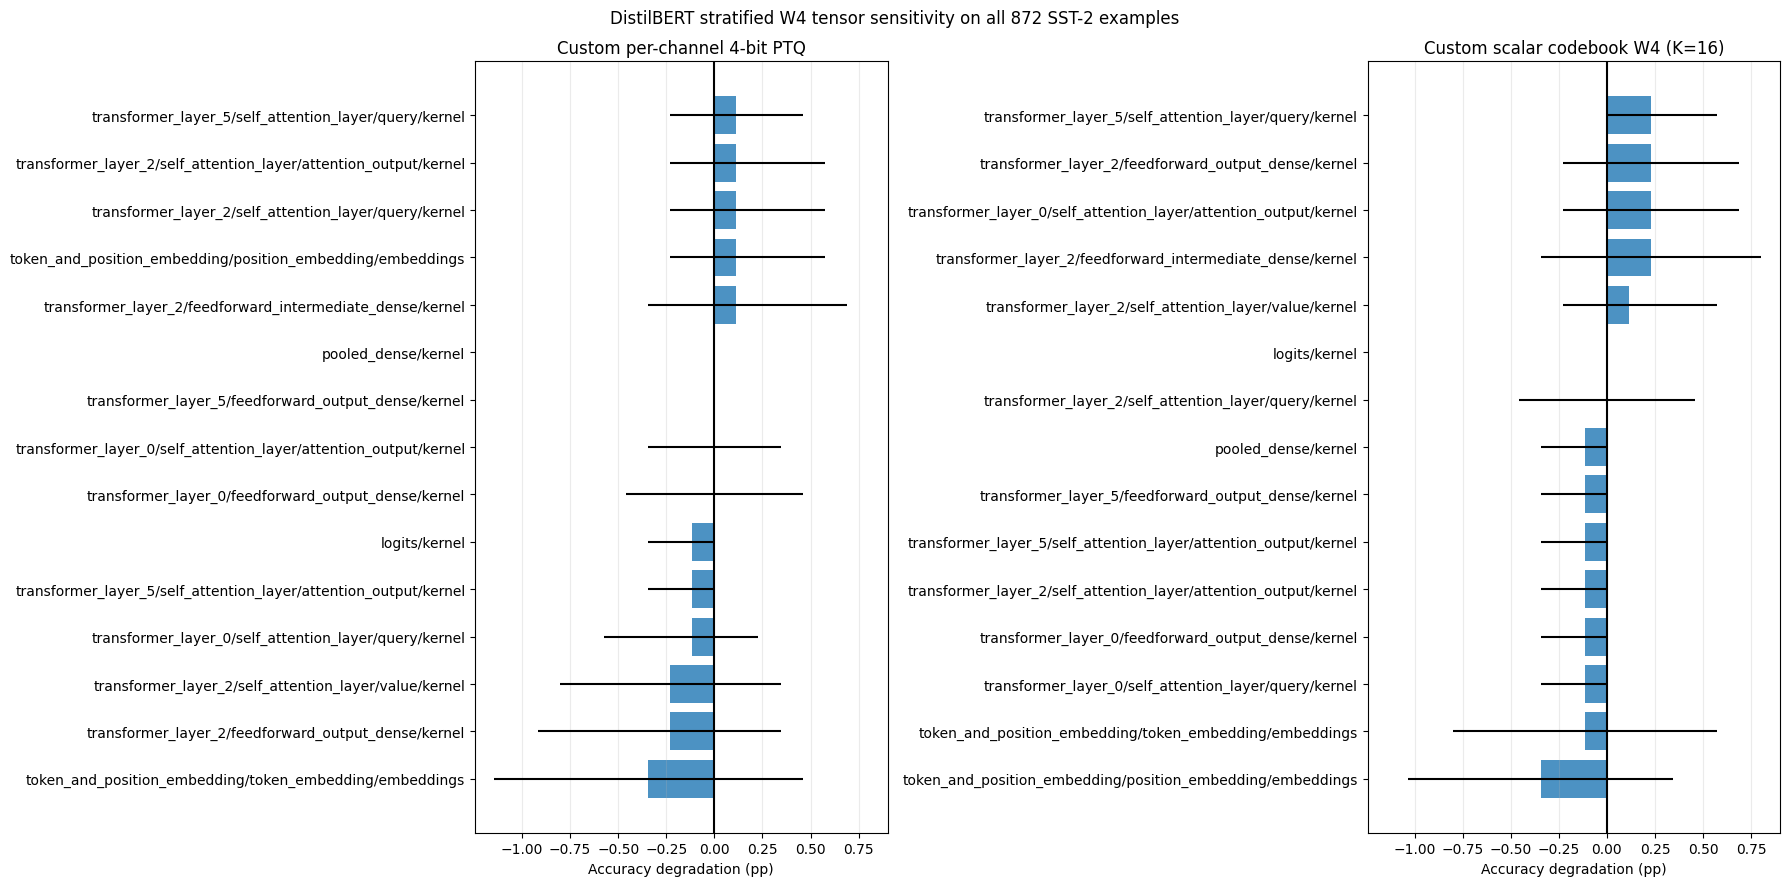

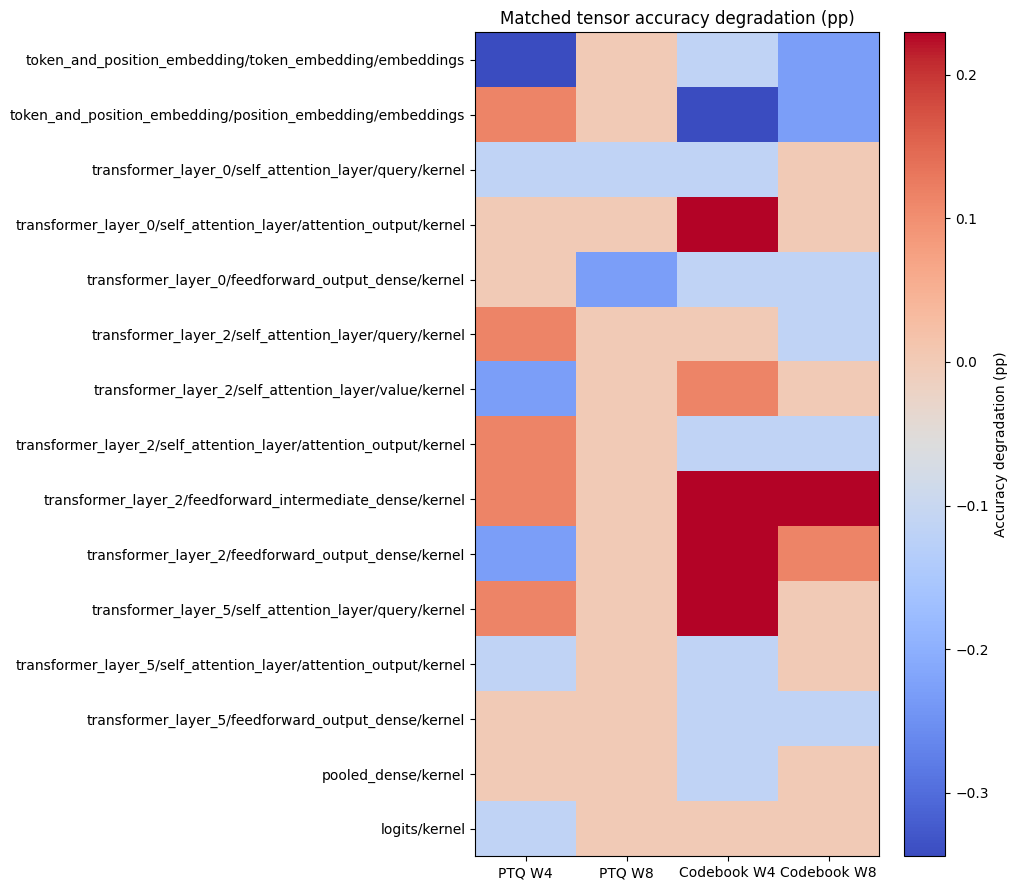

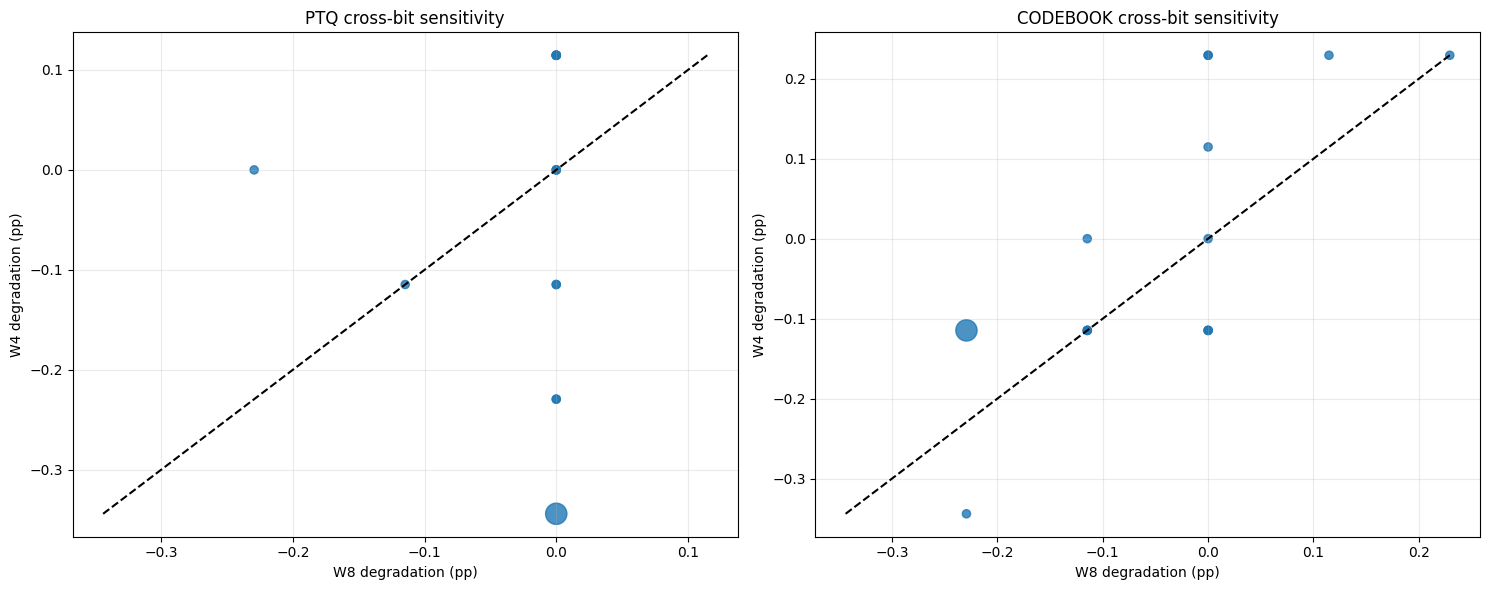

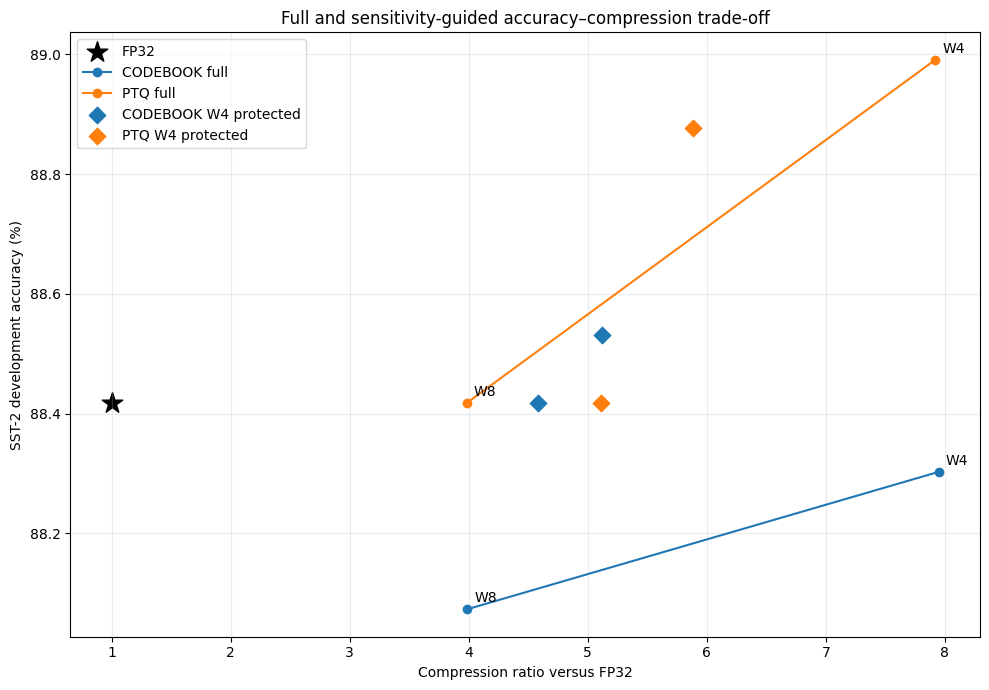

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True)
for axis, (method, label) in zip(axes, METHODS.items()):
    group = w4_results[w4_results.method == method].sort_values("accuracy_degradation_pp")
    lower = np.maximum(0, group.accuracy_degradation_pp - group.bootstrap_ci_low_pp); upper = np.maximum(0, group.bootstrap_ci_high_pp - group.accuracy_degradation_pp)
    axis.barh(group.tensor, group.accuracy_degradation_pp, xerr=[lower, upper], alpha=0.8); axis.axvline(0, color="black")
    axis.set_title(label); axis.set_xlabel("Accuracy degradation (pp)"); axis.grid(axis="x", alpha=0.25)
fig.suptitle("DistilBERT stratified W4 tensor sensitivity on all 872 SST-2 examples")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure1_stratified_w4_sensitivity.png", dpi=180, bbox_inches="tight"); plt.show()

heat = comparison.pivot(index="tensor", columns="method_family", values=["accuracy_degradation_pp_w4", "accuracy_degradation_pp_w8"]); heat.columns = [f"{family}_{metric.rsplit('_', 1)[-1]}" for metric, family in heat.columns]
heat = heat[["ptq_w4", "ptq_w8", "codebook_w4", "codebook_w8"]].loc[STRATIFIED_TENSORS]
fig, axis = plt.subplots(figsize=(10, 9)); image = axis.imshow(heat.to_numpy(), aspect="auto", cmap="coolwarm")
axis.set_xticks(range(4), ["PTQ W4", "PTQ W8", "Codebook W4", "Codebook W8"]); axis.set_yticks(range(len(heat)), heat.index); axis.set_title("Matched tensor accuracy degradation (pp)")
fig.colorbar(image, ax=axis, label="Accuracy degradation (pp)"); fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure2_w4_w8_heatmap.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, family in zip(axes, ("ptq", "codebook")):
    group = comparison[comparison.method_family == family]; axis.scatter(group.accuracy_degradation_pp_w8, group.accuracy_degradation_pp_w4, s=np.maximum(35, group.parameter_count / 100_000), alpha=0.8)
    lo = min(group.accuracy_degradation_pp_w8.min(), group.accuracy_degradation_pp_w4.min()); hi = max(group.accuracy_degradation_pp_w8.max(), group.accuracy_degradation_pp_w4.max())
    axis.plot([lo, hi], [lo, hi], "--", color="black"); axis.set_xlabel("W8 degradation (pp)"); axis.set_ylabel("W4 degradation (pp)"); axis.set_title(f"{family.upper()} cross-bit sensitivity"); axis.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure3_cross_bit_sensitivity.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axis = plt.subplots(figsize=(10, 7)); axis.scatter([1], [fp32_accuracy * 100], marker="*", s=240, color="black", label="FP32")
for family, group in full_model_comparison.groupby("method_family"):
    group = group.sort_values("bit_width"); axis.plot(group.compression_ratio_vs_fp32, group.accuracy_percent, "o-", label=f"{family.upper()} full")
    for row in group.itertuples(index=False): axis.annotate(f"W{row.bit_width}", (row.compression_ratio_vs_fp32, row.accuracy_percent), xytext=(5, 5), textcoords="offset points")
for family, group in w4_configurations.groupby("method_family"):
    protected = group[group.configuration != "full_w4"]; axis.scatter(protected.compression_ratio_vs_fp32, protected.accuracy_percent, marker="D", s=70, label=f"{family.upper()} W4 protected")
axis.set_xlabel("Compression ratio versus FP32"); axis.set_ylabel("SST-2 development accuracy (%)"); axis.set_title("Full and sensitivity-guided accuracy–compression trade-off"); axis.grid(alpha=0.25); axis.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure4_accuracy_compression_transfer.png", dpi=180, bbox_inches="tight"); plt.show()

## 11. Reproducibility record and report-ready outputs

In [16]:
stratified_table.to_csv(OUTPUT_DIR / "stratified_tensor_coverage.csv", index=False)
metadata = {
    "model_checkpoint": str(MODEL_PATH), "checkpoint_modified_time": MODEL_PATH.stat().st_mtime,
    "dataset": "GLUE SST-2 complete labelled development split", "evaluation_examples": NUM_EVALUATION_EXAMPLES,
    "preset": PRESET, "sequence_length": SEQUENCE_LENGTH, "bit_width": NUM_BITS,
    "complete_eligible_tensors": len(candidate_table), "isolated_sensitivity_tensors": len(stratified_table),
    "sampling_policy": "Predefined architecture-stratified embeddings/early/middle/late/output sample selected before W4 results.",
    "methods": METHODS, "ptq": {"symmetric": True, "per_channel": PTQ_PER_CHANNEL},
    "codebook": {"codebook_size": CODEBOOK_SIZE, "vector_dim": CODEBOOK_VECTOR_DIM, "dtype": str(CODEBOOK_DTYPE), "iterations": CODEBOOK_ITERATIONS},
    "w8_source": str(W8_OUTPUT_DIR), "protection_count": PROTECTION_COUNT, "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "storage_note": "W4 assignments use theoretical packed storage; PTQ scales and codebook centroids are included.",
    "activations_quantized": False, "fake_quantization_used": False,
    "selection_bias_warning": "Sensitivity-guided protection remains exploratory because the same labelled development split ranks and evaluates configurations.",
    "tensorflow_version": tf.__version__, "keras_version": keras.__version__, "scipy_version": scipy.__version__,
    "python_version": sys.version, "hardware": platform.platform(), "cache_version": CACHE_VERSION,
}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2, default=str))
print(f"All shortened W4 and W4/W8 comparison outputs saved under: {OUTPUT_DIR}")
print("Expected new inference evaluations: 37 maximum (1 FP32 + 30 isolated + 6 full/selective); cache hits reduce reruns.")

All shortened W4 and W4/W8 comparison outputs saved under: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/distilbert_4bit_stratified_sensitivity
Expected new inference evaluations: 37 maximum (1 FP32 + 30 isolated + 6 full/selective); cache hits reduce reruns.


## Interpretation rules

- Notebook 18 provides the complete 40-tensor W8 census; this notebook estimates cross-bit behaviour on a predefined 15-tensor architectural sample.
- Do not generalize the sampled W4 ranking to every DistilBERT tensor.
- Cross-bit rank stability tests whether W8 sensitivity persists at W4; low correlation means W8 rankings should not automatically guide lower-precision allocation.
- W8-guided W4 protection is an exploratory transfer experiment, not proof of generalization, because ranking and evaluation use the same SST-2 development split.
- Individual effects are not additive, and unchanged aggregate accuracy may hide different predictions or class-specific error shifts.
- Reconstructed FP32 Keras inference measures accuracy effects and estimated storage, not native 4-bit latency, energy or physical packed-memory use.